# 03 - Neural network, feature selection and results
This notebook reads the tables produced by `python -m scripts.run_experiments` (run it first; it takes about 10 minutes) and discusses the results.

In [1]:
import sys, pathlib, warnings
sys.path.insert(0, str(pathlib.Path.cwd().parent))
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import pandas as pd
from src.config import TABLES_DIR
from src import viz
comparison = pd.read_csv(TABLES_DIR / 'model_comparison.csv')
sweep = pd.read_csv(TABLES_DIR / 'neuron_sweep.csv')
predictions = pd.read_csv(TABLES_DIR / 'lodo_predictions.csv')
frequency = pd.read_csv(TABLES_DIR / 'selection_frequency.csv')
selection = pd.read_csv(TABLES_DIR / 'selection_summary.csv')
pca = pd.read_csv(TABLES_DIR / 'pca_sweep.csv')

## 1. Reproducing the paper (random 5-fold CV)
`paper_mse` is Table I of Krimsky & Ng (2018). Our `nn` is tuned by *nested* CV (hidden size and L2 strength are picked on training folds only), so it is a slightly stricter number than the paper's best-of-sweep value.

In [2]:
kf = comparison[(comparison.protocol == 'kfold') & comparison.model.isin(['constant', 'lasso', 'nn'])]
kf.pivot_table(index=['subject', 'feature_set'], columns='model', values=['mse', 'paper_mse']).round(4)

mse                 paper_mse                
model               constant   lasso      nn  constant   lasso      nn
subject feature_set                                                   
S1      all           0.0666  0.0091  0.0101    0.0657  0.0089  0.0089
        emg           0.0666  0.0186  0.0135    0.0657  0.0158  0.0118
        step          0.0666  0.0215  0.0149    0.0657  0.0200  0.0138
        step_emg      0.0666  0.0099  0.0105    0.0657  0.0089  0.0104
S2      all           0.0362  0.0135  0.0150    0.0465  0.0176  0.0301
        emg           0.0362  0.0181  0.0160    0.0465  0.0203  0.0199
        step          0.0362  0.0216  0.0163    0.0465  0.0217  0.0233
        step_emg      0.0362  0.0145  0.0148    0.0465  0.0168  0.0313

## 2. Neural-network size (paper Fig. 1, now with leave-one-day-out)

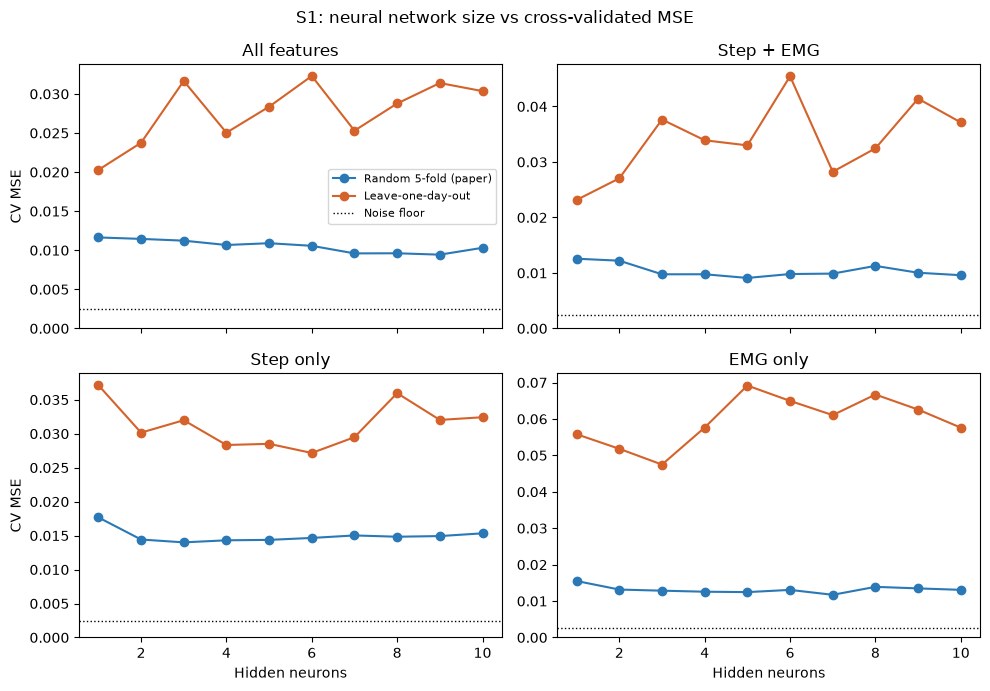

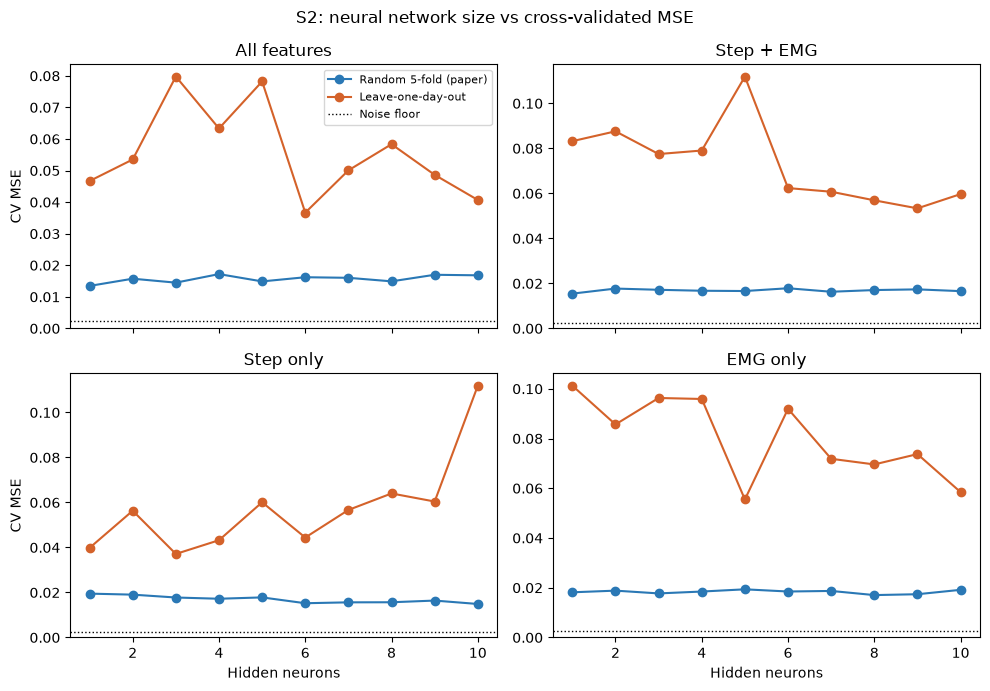

In [3]:
for s in ['S1', 'S2']:
    viz.plot_neuron_sweep(sweep, s)
plt.show()

As in the paper, small networks (1-4 neurons) are enough; more neurons do not help on 180 samples.

## 3. Random k-fold vs leave-one-day-out

In [4]:
summary = comparison.pivot_table(index=['subject', 'feature_set', 'model'], columns='protocol', values='mse')
summary['lodo / kfold'] = summary.lodo / summary.kfold
summary.round(4)

protocol                       kfold    lodo  lodo / kfold
subject feature_set model                                 
S1      all         constant  0.0666  0.0917        1.3763
                    lasso     0.0091  0.0205        2.2404
                    nn        0.0101  0.0223        2.2128
                    ridge     0.0086  0.0143        1.6725
        emg         constant  0.0666  0.0917        1.3763
                    lasso     0.0186  0.0636        3.4239
                    nn        0.0135  0.0511        3.7757
                    ridge     0.0185  0.0579        3.1268
        step        constant  0.0666  0.0917        1.3763
                    lasso     0.0215  0.0352        1.6353
                    nn        0.0149  0.0328        2.2042
                    ridge     0.0199  0.0363        1.8244
        step_emg    constant  0.0666  0.0917        1.3763
                    lasso     0.0099  0.0260        2.6327
                    nn        0.0105  0.0273        2.5917
                    ridge     0.0093  0.0164        1.7509
S2      all         constant  0.0362  0.0478        1.3226
                    lasso     0.0135  0.0309        2.2927
                    nn        0.0150  0.0315        2.0986
                    ridge     0.0146  0.0358        2.4546
        emg         constant  0.0362  0.0478        1.3226
                    lasso     0.0181  0.0444        2.4456
                    nn        0.0160  0.0450        2.8171
                    ridge     0.0174  0.0449        2.5788
        step        constant  0.0362  0.0478        1.3226
                    lasso     0.0216  0.0476        2.2085
                    nn        0.0163  0.0616        3.7754
                    ridge     0.0212  0.0541        2.5469
        step_emg    constant  0.0362  0.0478        1.3226
                    lasso     0.0145  0.0448        3.0813
                    nn        0.0148  0.0632        4.2755
                    ridge     0.0144  0.0493        3.4234

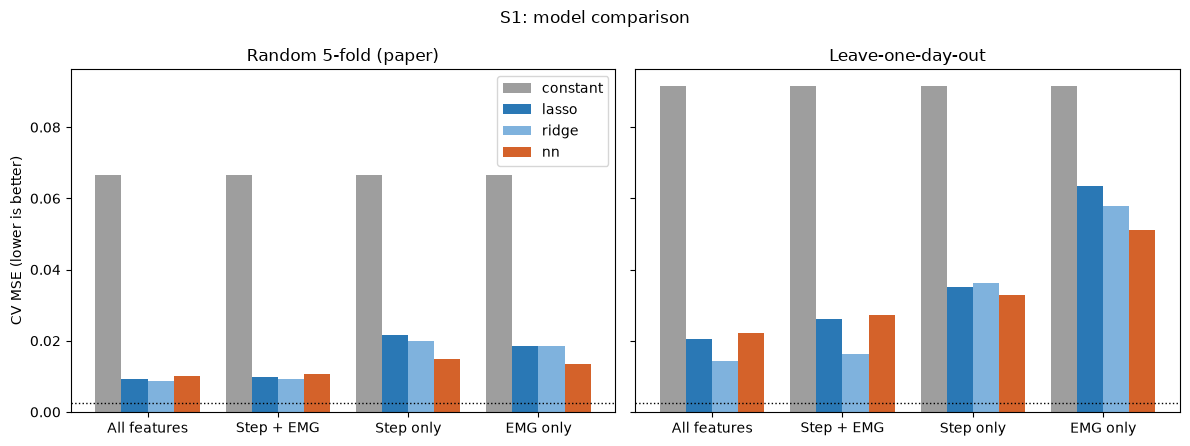

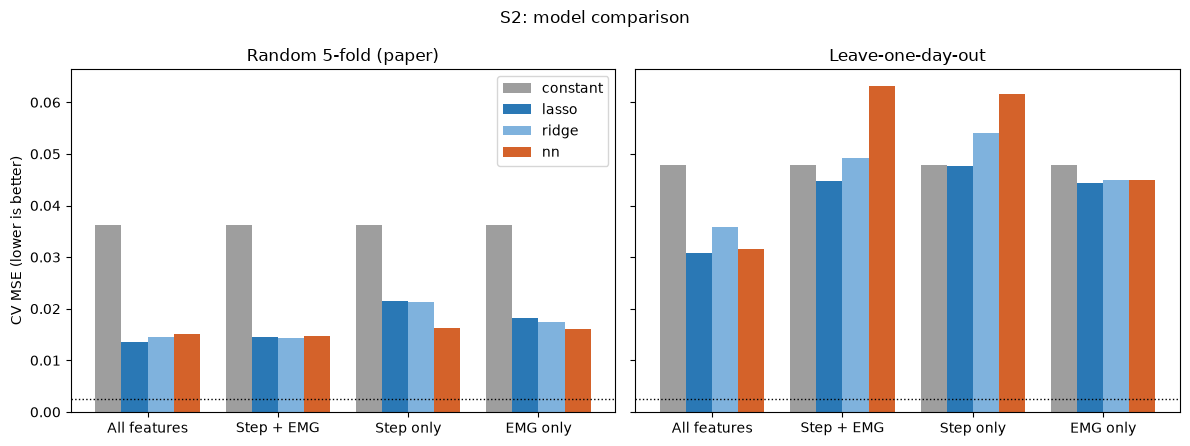

In [5]:
for s in ['S1', 'S2']:
    viz.plot_model_comparison(comparison, s)
plt.show()

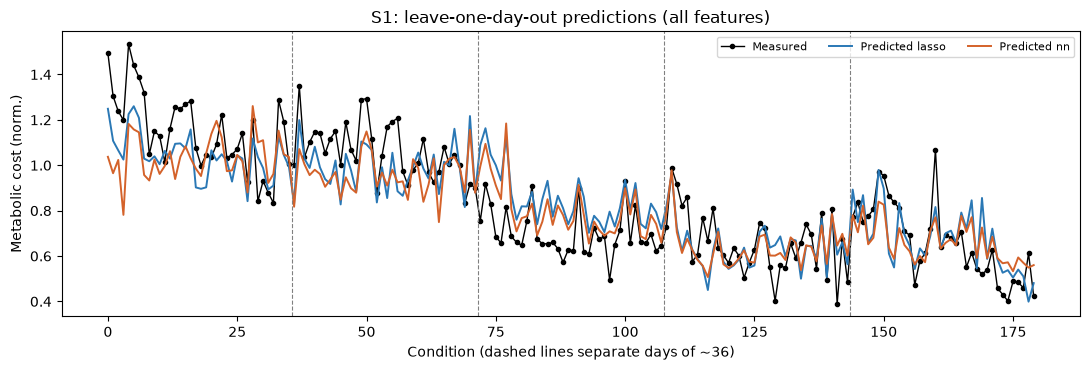

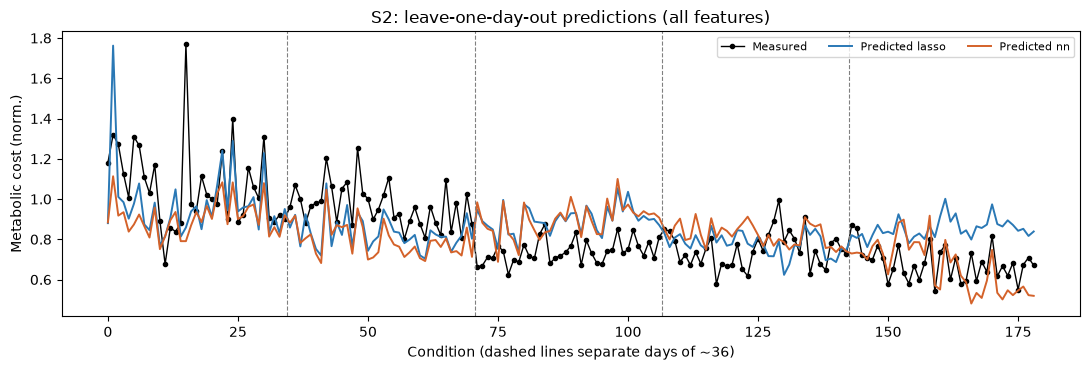

In [6]:
for s in ['S1', 'S2']:
    viz.plot_lodo_predictions(predictions, s)
plt.show()

## 4. Dimensionality reduction (nested inside CV)

In [7]:
selection.round(4)

,subject,protocol,mse,features_always_selected
0,S1,kfold,0.0132,4
1,S1,lodo,0.0460,1
2,S2,kfold,0.0120,2
3,S2,lodo,0.0460,0


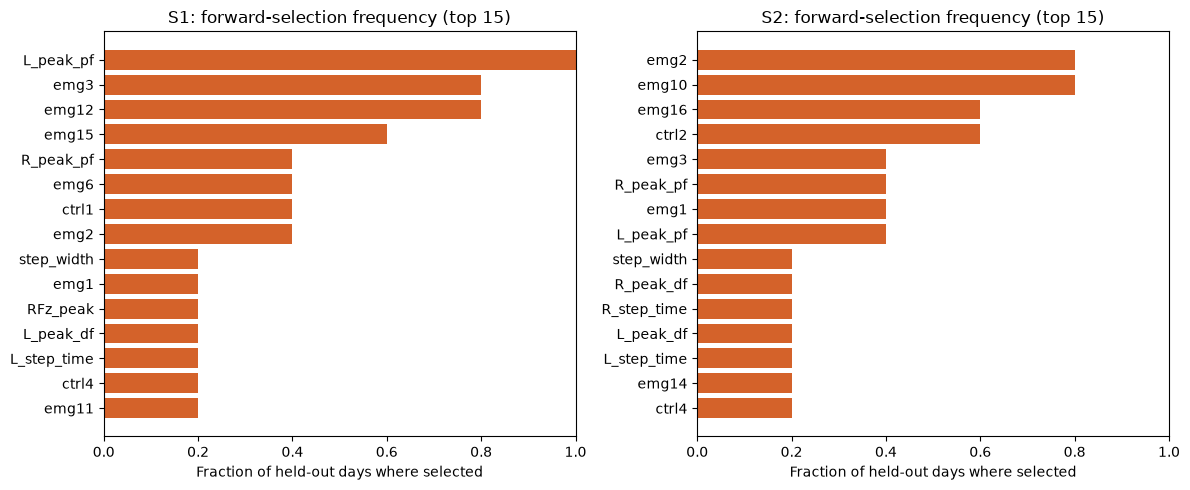

In [8]:
viz.plot_selection_frequency(frequency)
plt.show()

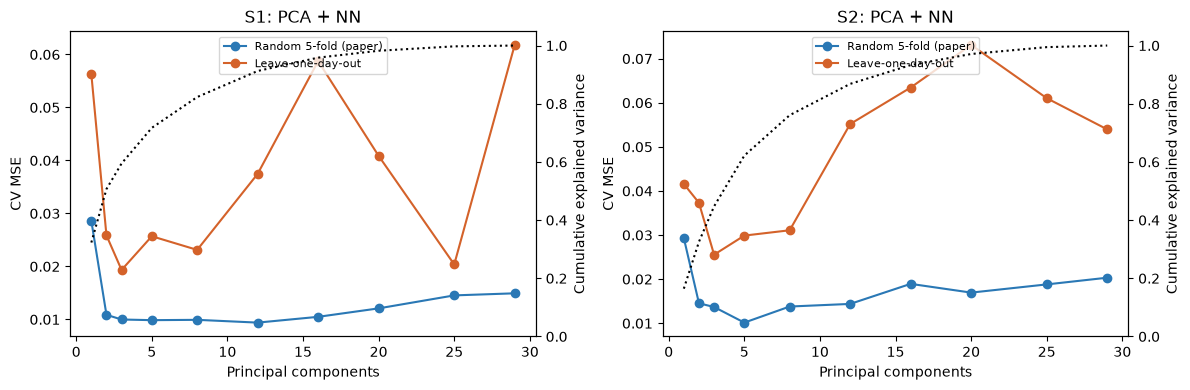

In [9]:
viz.plot_pca_sweep(pca)
plt.show()

## Findings
1. **Reproduction**: with the paper's random k-fold protocol we obtain errors of the same size as Table I (S1, all features: LASSO 0.0091 vs 0.0089 in the paper), far below the constant-prediction error (0.067).
2. **Generalising to a new day is much harder**: holding out a whole day roughly doubles the error (S1 LASSO 0.0091 -> 0.0205, S2 0.0135 -> 0.0309). For S2 the best model explains only about 14% of the variance of an unseen day. Random k-fold lets the model see other conditions from the same day, so it over-states real-world accuracy.
3. **Linear vs neural**: with all features, regularised linear models are as good as the nested-tuned NN (S1 Ridge 0.0086 / 0.0143 for k-fold / LODO). The NN only helps on the small feature sets (step-only, EMG-only), where some non-linearity is useful. Under LODO, larger networks get worse (see the neuron sweep), i.e. they over-fit day-specific patterns.
4. **Feature sets**: step + EMG beats either group alone. The 4 control parameters help clearly under LODO (S2 LASSO 0.0448 -> 0.0309), probably because the optimiser's settings drift across days and so encode how far the subject has adapted.
5. **Selection / PCA**: nested forward selection is worse than using all features (LODO MSE about 0.046), and the selected features change between held-out days - the same instability the paper reports. PCA helps a little under k-fold (S1: 12 components, 0.0094) but is erratic under LODO, because components are chosen for variance, not for predicting the target.